In [1]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time

import sys

sys.path.append("../..")

from src import IOFunctions


from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter(dark_background=True)

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

In [2]:
import types

smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

In [3]:
R, G, B, wavelength = S_F.getpixelefficiency(
    filename="/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Code/Python/pyBayerSMLM/Spectra/Camera_QE/CS505CU_QE.csv"
)
readnoise = 0.01
QY_parameters = 0.67

In [4]:
image_size = 12
camera_parameters = {}
masks = M_F.get_masks(size_x=image_size, size_y=image_size)
gain = 1.0
camera_parameters["gain"] = np.full((image_size, image_size), gain)
camera_parameters["offset"] = np.full((image_size, image_size), 32)
readnoise = readnoise
camera_parameters["readnoise"] = np.full((image_size, image_size), readnoise)
variance = np.square(gain * readnoise)
camera_parameters["variance"] = np.full((image_size, image_size), variance)
camera_parameters["rqe"] = np.full((image_size, image_size), 1)
pixel_QYs = np.vstack([B, G, R])
scaling_factor = QY_parameters / np.max(pixel_QYs)
camera_parameters["pixel_QYs"] = np.vstack([B, G, R]) * scaling_factor
camera_parameters["pixel_order"] = ["B", "G", "R"]
camera_parameters["pixel_order_indices"] = [0, 1, 2]
camera_parameters["masks"] = M_F.get_masks(size_x=image_size, size_y=image_size)

In [ ]:
folder = "/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Code/Python/pyBayerSMLM/Spectra/Camera_QE/"
prime95B_QE_data = pl.read_csv(os.path.join(folder, "Prime95B.csv"), has_header=False)
prime95B_QE = np.interp(
    wavelength, prime95B_QE_data["column_1"], prime95B_QE_data["column_2"] / 100
)

In [ ]:
gain = 1.0
readnoise = 15.0
highQY_camera_parameters = {}
highQY_camera_parameters["gain"] = np.full((image_size, image_size), gain)
highQY_camera_parameters["offset"] = np.full((image_size, image_size), 32.0)
highQY_camera_parameters["readnoise"] = np.full((image_size, image_size), readnoise)
variance = np.square(gain * readnoise)
highQY_camera_parameters["variance"] = np.full((image_size, image_size), variance)

highQE = np.expand_dims(prime95B_QE, axis=0)
highQE = (highQE / np.max(highQE)) * 0.99
highQY_camera_parameters["rqe"] = np.full((image_size, image_size), 1)
highQY_camera_parameters["pixel_QYs"] = highQE
highQY_camera_parameters["pixel_order"] = ["W"]
highQY_camera_parameters["pixel_order_indices"] = [0]
masks_fake = {}
masks_fake["W"] = np.ones_like(np.full((image_size, image_size), 1.0))
highQY_camera_parameters["masks"] = masks_fake

In [ ]:
gain = 1.0
readnoise = 0.01
highQY_lowRN_camera_parameters = {}
highQY_lowRN_camera_parameters["gain"] = np.full((image_size, image_size), gain)
highQY_lowRN_camera_parameters["offset"] = np.full((image_size, image_size), 32.0)
highQY_lowRN_camera_parameters["readnoise"] = np.full(
    (image_size, image_size), readnoise
)
variance = np.square(gain * readnoise)
highQY_lowRN_camera_parameters["variance"] = np.full((image_size, image_size), variance)

highQE = np.expand_dims(prime95B_QE, axis=0)
highQE = (highQE / np.max(highQE)) * 0.99
highQY_lowRN_camera_parameters["rqe"] = np.full((image_size, image_size), 1)
highQY_lowRN_camera_parameters["pixel_QYs"] = highQE
highQY_lowRN_camera_parameters["pixel_order"] = ["W"]
highQY_lowRN_camera_parameters["pixel_order_indices"] = [0]
masks_fake = {}
masks_fake["W"] = np.ones_like(np.full((image_size, image_size), 1.0))
highQY_lowRN_camera_parameters["masks"] = masks_fake

In [ ]:
gain = 1.0
readnoise = 0.01
lowQY_camera_parameters = {}
lowQY_camera_parameters["gain"] = np.full((image_size, image_size), gain)
lowQY_camera_parameters["offset"] = np.full((image_size, image_size), 32.0)
lowQY_camera_parameters["readnoise"] = np.full((image_size, image_size), readnoise)
variance = np.square(gain * readnoise)
lowQY_camera_parameters["variance"] = np.full((image_size, image_size), variance)

lowQE = np.expand_dims(prime95B_QE, axis=0)
lowQE = (lowQE / np.max(lowQE)) * 0.4
lowQY_camera_parameters["rqe"] = np.full((image_size, image_size), 1)
lowQY_camera_parameters["pixel_QYs"] = lowQE
lowQY_camera_parameters["pixel_order_indices"] = [0]
masks_fake = {}
masks_fake["W"] = np.ones_like(np.full((image_size, image_size), 1.0))
lowQY_camera_parameters["masks"] = masks_fake

In [ ]:
gain = 1.0
readnoise = 15
lowQY_highRN_camera_parameters = {}
lowQY_highRN_camera_parameters["gain"] = np.full((image_size, image_size), gain)
lowQY_highRN_camera_parameters["offset"] = np.full((image_size, image_size), 32.0)
lowQY_highRN_camera_parameters["readnoise"] = np.full(
    (image_size, image_size), readnoise
)
variance = np.square(gain * readnoise)
lowQY_highRN_camera_parameters["variance"] = np.full((image_size, image_size), variance)

lowQE = np.expand_dims(prime95B_QE, axis=0)
lowQE = (highQE / np.max(highQE)) * 0.4
lowQY_highRN_camera_parameters["rqe"] = np.full((image_size, image_size), 1)
lowQY_highRN_camera_parameters["pixel_QYs"] = lowQE
lowQY_highRN_camera_parameters["pixel_order"] = ["W"]
lowQY_highRN_camera_parameters["pixel_order_indices"] = [0]
masks_fake = {}
masks_fake["W"] = np.ones_like(np.full((image_size, image_size), 1.0))
lowQY_highRN_camera_parameters["masks"] = masks_fake

In [5]:
dyes = ["ATTO 488", "ATTO 550", "ATTO 647N"]
n_photon = 4000
n_background = 4
pixel_size = 69
NA = 1.49
scaleparam = 16
s = scaleparam * scaleparam * 2


notch_filter = "semrock-nf03-405-488-561-635e"
dichroic_mirror = "semrock-di03-r405-488-561-635-t1-25x36"
nilered_filter = "semrock-ff01-650-200-25"
shortpass_filter = "semrock-bsp01-785r"
filters = []

In [ ]:
dye = "ATTO 647N"
n_photons = {}
n_photons[dye] = np.full(1, n_photon)

dye_matrix = np.zeros([1, len(wavelength)])

x0y0 = {}
max = pixel_size * image_size

average_emission_wavelengths, dye_pixel_efficiency = (
    S_F.get_pixel_fractions_dye_and_filters(
        dye, filters, wavelength, highQY_camera_parameters["pixel_QYs"][0]
    )
)
x0 = 5.5 * pixel_size
y0 = 5.5 * pixel_size
for dye in n_photons:
    x0y0[dye] = np.zeros([s, 2, 1])
    x0y0[dye][:, :, :] = np.array([[y0, x0]]).T

average_emission_wavelengths, dye_pixel_efficiency = (
    S_F.get_pixel_fractions_dye_and_filters(
        dye, filters, wavelength, highQY_camera_parameters["pixel_QYs"][0]
    )
)

images_for_figure_highQY_highRN, _, _ = MSF.gen_camera_image_stack(
    highQY_camera_parameters,
    wavelength,
    np.array(average_emission_wavelengths),
    np.array(dye_pixel_efficiency),
    n_photons,
    x0y0,
    background_photons=n_background,
    smoothing_function=smoothing_function,
    NA=NA,
    pixel_size=pixel_size,
    return_normal_image=False,
)

images_for_figure_highQY_lowRN, _, _ = MSF.gen_camera_image_stack(
    highQY_lowRN_camera_parameters,
    wavelength,
    np.array(average_emission_wavelengths),
    np.array(dye_pixel_efficiency),
    n_photons,
    x0y0,
    background_photons=n_background,
    smoothing_function=smoothing_function,
    NA=NA,
    pixel_size=pixel_size,
    return_normal_image=False,
)

average_emission_wavelengths, dye_pixel_efficiency = (
    S_F.get_pixel_fractions_dye_and_filters(
        dye, filters, wavelength, lowQY_camera_parameters["pixel_QYs"][0]
    )
)

images_for_figure_lowQY_lowRN, _, _ = MSF.gen_camera_image_stack(
    lowQY_camera_parameters,
    wavelength,
    np.array(average_emission_wavelengths),
    np.array(dye_pixel_efficiency),
    n_photons,
    x0y0,
    background_photons=n_background,
    smoothing_function=smoothing_function,
    NA=NA,
    pixel_size=pixel_size,
    return_normal_image=False,
)

images_for_figure_lowQY_highRN, _, _ = MSF.gen_camera_image_stack(
    lowQY_highRN_camera_parameters,
    wavelength,
    np.array(average_emission_wavelengths),
    np.array(dye_pixel_efficiency),
    n_photons,
    x0y0,
    background_photons=n_background,
    smoothing_function=smoothing_function,
    NA=NA,
    pixel_size=pixel_size,
    return_normal_image=False,
)

In [ ]:
vmin, vmax = np.percentile(images_for_figure_highQY_lowRN, (0.1, 99))

In [ ]:
fig, axs = plotter.one_column_plot()

axs = plotter.image_plot(
    axs=axs,
    data=images_for_figure_highQY_highRN,
    cbar="off",
    scalebarsize=300,
    scalebarlabel="300 nm",
    vmax=vmax,
    vmin=vmin,
)


folder = "/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Conference Presentations/20250627_RSCPhotochem/fig/multicolour_camera/setup/"
if not os.path.isdir(folder):
    os.mkdir(folder)
plt.savefig(os.path.join(folder, "highQY_highRN.svg"), format="svg", dpi=600)

plt.show()

In [ ]:
fig, axs = plotter.two_column_plot(ncolumns=2, widthratio=[1, 1])

axs[0] = plotter.image_plot(
    axs=axs[0],
    data=images_for_figure_highQY,
    scalebarsize=300,
    scalebarlabel="300 nm",
    cbarlabel="photoelectrons",
)

axs[1] = plotter.image_plot(
    axs=axs[1],
    data=images_for_figure_lowQY,
    scalebarsize=300,
    scalebarlabel="300 nm",
    cbarlabel="photoelectrons",
)

# folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Conference Presentations/20250627_RSCPhotochem/fig/multicolour_camera/setup/'
# if not os.path.isdir(folder):
#    os.mkdir(folder)
# plt.savefig(os.path.join(folder, 'LowQY_vs_HighQY_cbar.svg'), format='svg', dpi=600)

plt.show()

In [6]:
image_dim = pixel_size * np.array(camera_parameters["gain"].shape)
x0r = np.linspace(1 * pixel_size, 3 * pixel_size, scaleparam)
y0r = np.linspace(1 * pixel_size, 3 * pixel_size, scaleparam)
Y, X = np.meshgrid(x0r, y0r)
Y[1::2] = Y[1::2, ::-1]
x0 = X.ravel()
x0 = np.concatenate([x0, x0[::-1]])
y0 = Y.ravel()
y0 = np.concatenate([y0, y0[::-1]])
xpositions = x0 / pixel_size
ypositions = y0 / pixel_size

In [7]:
image_dim = pixel_size * np.array(camera_parameters["gain"].shape)
images_for_figures = np.zeros([len(dyes), s, image_size, image_size])
x0r = np.linspace(6.5 * pixel_size, 4.5 * pixel_size, scaleparam)
y0r = np.linspace(4.5 * pixel_size, 6.5 * pixel_size, scaleparam)
Y, X = np.meshgrid(x0r, y0r)
Y[1::2] = Y[1::2, ::-1]
x0 = X.ravel()
x0 = np.concatenate([x0, x0[::-1]])
y0 = Y.ravel()
y0 = np.concatenate([y0, y0[::-1]])

for j, dye in enumerate(dyes):
    n_photons = {}
    n_photons[dye] = np.full(s, n_photon)

    dye_matrix = np.zeros([1, len(wavelength)])

    x0y0 = {}
    max = pixel_size * image_size

    average_emission_wavelengths, dye_pixel_efficiency = (
        S_F.get_pixel_fractions_dye_and_filters(
            dye, filters, wavelength, camera_parameters["pixel_QYs"]
        )
    )

    for dye in n_photons:
        x0y0[dye] = np.zeros([s, 2, 1])
        x0y0[dye][:, :, :] = np.array([[y0, x0]]).T
    images_for_figures[j, :, :, :], _, _ = MSF.gen_camera_image_stack(
        camera_parameters,
        wavelength,
        average_emission_wavelengths,
        dye_pixel_efficiency,
        n_photons,
        x0y0,
        background_photons=n_background,
        smoothing_function=smoothing_function,
        NA=NA,
        pixel_size=pixel_size,
        return_normal_image=False,
    )

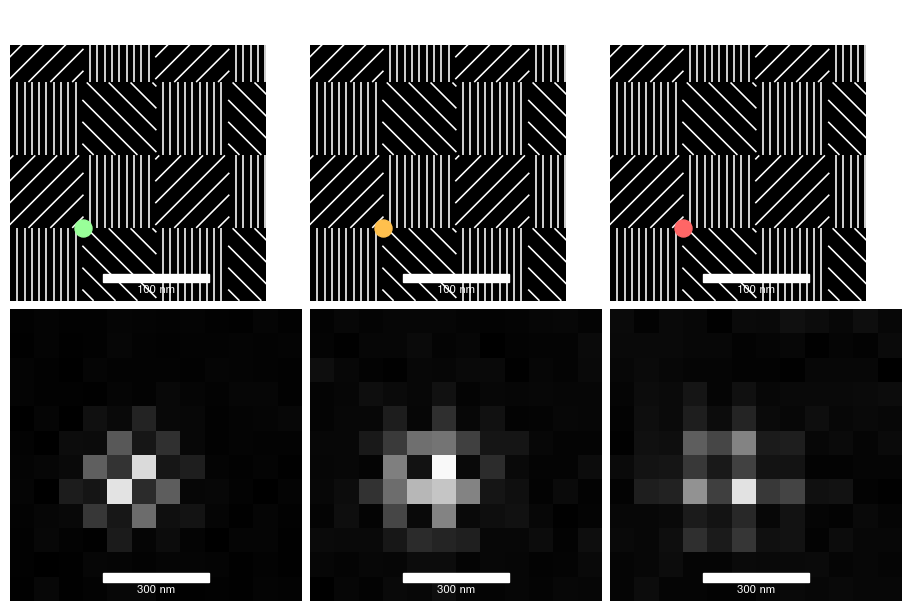

In [9]:
fig, axs = plotter.two_column_plot(
    nrows=2, ncolumns=3, heightratio=[1, 1], widthratio=[1, 1, 1], width=9, height=6
)
plot_types = np.array([["pattern", "pattern", "pattern"], ["image", "image", "image"]])
folder = "/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Conference Presentations/20250627_RSCPhotochem/fig/multicolour_camera/what_would_it_look_like/"
plotter.make_animated_gif_multipanel(
    fig,
    axs,
    plot_types,
    xpositions,
    ypositions,
    images_for_figures,
    n_pixels=4,
    n_frames=s,
    filename=os.path.join(folder, "ATTO_dyes.gif"),
)

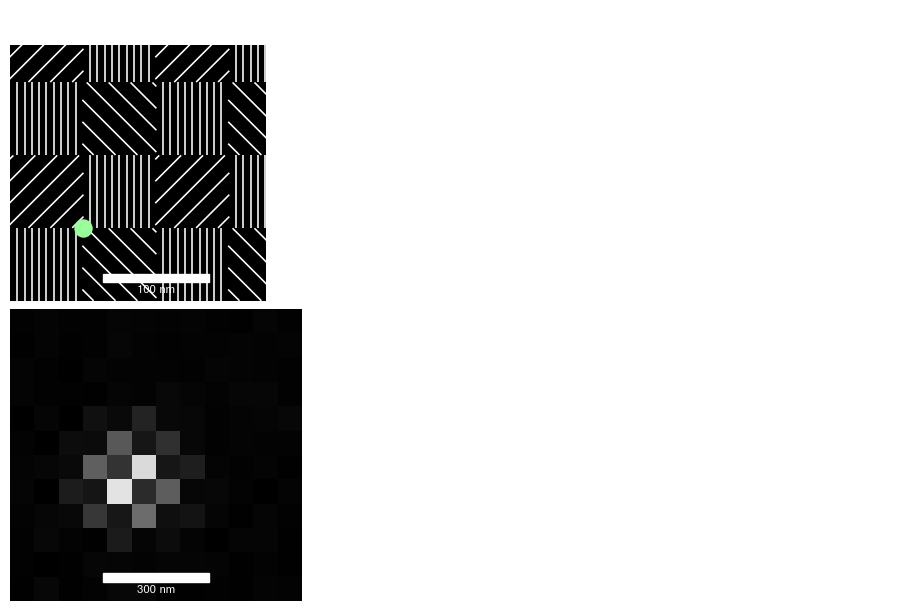

In [8]:
fig, axs = plotter.two_column_plot(
    nrows=2, ncolumns=3, heightratio=[1, 1], widthratio=[1, 1, 1], width=9, height=6
)
plot_types = np.array([["pattern", "off", "off"], ["image", "off", "off"]])
folder = "/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Conference Presentations/20250627_RSCPhotochem/fig/multicolour_camera/what_would_it_look_like/"
plotter.make_animated_gif_multipanel(
    fig,
    axs,
    plot_types,
    xpositions,
    ypositions,
    images_for_figures,
    n_pixels=4,
    n_frames=s,
    filename=os.path.join(folder, "ATTO_488_example.gif"),
)

In [ ]:
width = 7.20472
height = 7.20472

In [ ]:
from matplotlib.gridspec import GridSpec

from scipy.interpolate import make_smoothing_spline
from scipy.optimize import curve_fit

fig = plt.figure(layout="constrained", figsize=(width, height))


gs = GridSpec(11, 11, figure=fig)

for i in np.arange(11):
    for j in np.arange(11):
        if i == 0 and j == 0:
            continue
        elif i == 0 and j > 0:
            ax = fig.add_subplot(gs[i, j])
            ax = plot_bayer_mask(
                ax=ax, pattern="GBRG", size=8, vline=y0r[j - 1] / pixel_size + 3.5
            )
        elif j == 0 and i > 0:
            ax = fig.add_subplot(gs[i, j])
            ax = plot_bayer_mask(
                ax=ax, pattern="GBRG", size=8, hline=x0r[::-1][i - 1] / pixel_size + 3.5
            )
        else:
            ax = fig.add_subplot(gs[i, j])
            ax = plotter.image_plot(
                axs=ax,
                data=images_for_figures[0, (i - 1), (j - 1), :, :].T,
                cbar="off",
                sbar="off",
            )

folder = "/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Papers/Multicolour/SI"
if not os.path.isdir(folder):
    os.mkdir(folder)
plt.savefig(os.path.join(folder, "ATTO488_Grid.svg"), format="svg", dpi=600)
plt.show()

In [ ]:
from matplotlib.gridspec import GridSpec

from scipy.interpolate import make_smoothing_spline
from scipy.optimize import curve_fit

fig = plt.figure(layout="constrained", figsize=(width, height))


gs = GridSpec(11, 11, figure=fig)

for i in np.arange(11):
    for j in np.arange(11):
        if i == 0 and j == 0:
            continue
        elif i == 0 and j > 0:
            ax = fig.add_subplot(gs[i, j])
            ax = plot_bayer_mask(
                ax=ax, pattern="GBRG", size=8, vline=y0r[j - 1] / pixel_size + 3.5
            )
        elif j == 0 and i > 0:
            ax = fig.add_subplot(gs[i, j])
            ax = plot_bayer_mask(
                ax=ax, pattern="GBRG", size=8, hline=x0r[::-1][i - 1] / pixel_size + 3.5
            )
        else:
            ax = fig.add_subplot(gs[i, j])
            ax = plotter.image_plot(
                axs=ax,
                data=images_for_figures[1, (i - 1), (j - 1), :, :].T,
                cbar="off",
                sbar="off",
            )

folder = "/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Papers/Multicolour/SI"
if not os.path.isdir(folder):
    os.mkdir(folder)
plt.savefig(os.path.join(folder, "ATTO565_Grid.svg"), format="svg", dpi=600)
plt.show()

In [ ]:
from matplotlib.gridspec import GridSpec

from scipy.interpolate import make_smoothing_spline
from scipy.optimize import curve_fit

fig = plt.figure(layout="constrained", figsize=(width, height))


gs = GridSpec(11, 11, figure=fig)

for i in np.arange(11):
    for j in np.arange(11):
        if i == 0 and j == 0:
            continue
        elif i == 0 and j > 0:
            ax = fig.add_subplot(gs[i, j])
            ax = plot_bayer_mask(
                ax=ax, pattern="GBRG", size=8, vline=y0r[j - 1] / pixel_size + 3.5
            )
        elif j == 0 and i > 0:
            ax = fig.add_subplot(gs[i, j])
            ax = plot_bayer_mask(
                ax=ax, pattern="GBRG", size=8, hline=x0r[::-1][i - 1] / pixel_size + 3.5
            )
        else:
            ax = fig.add_subplot(gs[i, j])
            ax = plotter.image_plot(
                axs=ax,
                data=images_for_figures[2, (i - 1), (j - 1), :, :].T,
                cbar="off",
                sbar="off",
            )

folder = "/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Papers/Multicolour/SI"
if not os.path.isdir(folder):
    os.mkdir(folder)
plt.savefig(os.path.join(folder, "ATTO647N_Grid.svg"), format="svg", dpi=600)
plt.show()